In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = yf.download(['NG=F','CL=F'], start='2010-01-01')['Close']
df.dropna()

[*********************100%***********************]  2 of 2 completed


Ticker,CL=F,NG=F
Date,,
2010-01-04,81.510002,5.884
2010-01-05,81.769997,5.637
2010-01-06,83.180000,6.009
2010-01-07,82.660004,5.806
2010-01-08,82.750000,5.749
...,...,...
2026-05-22,96.599998,2.907
2026-05-26,93.889999,2.894
2026-05-27,88.680000,3.040


# Calculating log returns

In [4]:
log_returns = np.log(df/df.shift(1)).dropna()
log_returns

C:\Users\KUNAL\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


Ticker,CL=F,NG=F
Date,,
2010-01-05,0.003185,-0.042885
2010-01-06,0.017097,0.063906
2010-01-07,-0.006271,-0.034366
2010-01-08,0.001088,-0.009866
2010-01-11,-0.002783,-0.052677
...,...,...
2026-05-22,0.002591,-0.037473
2026-05-26,-0.028455,-0.004482
2026-05-27,-0.057089,0.049218


In [5]:
ng_returns = np.log(df['NG=F']/df['NG=F'].shift(1)).dropna()
ng_returns

Date
2010-01-05   -0.042885
2010-01-06    0.063906
2010-01-07   -0.034366
2010-01-08   -0.009866
2010-01-11   -0.052677
                ...   
2026-05-22   -0.037473
2026-05-26   -0.004482
2026-05-27    0.049218
2026-05-28    0.077509
2026-05-29    0.001521
Name: NG=F, Length: 4126, dtype: float64

# Calculating Rolling Volatility (Signal)

<Axes: title={'center': 'Natural Gas Rolling Volatility (60D)'}, xlabel='Date'>

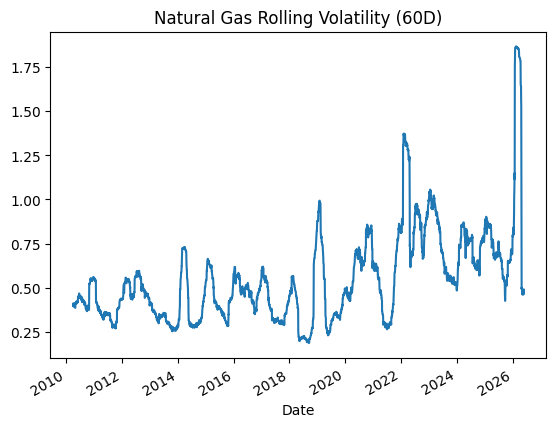

In [7]:
window = 60

Ng_volatility= ng_returns.rolling(window).std() * np.sqrt(252)
Ng_volatility.plot(title='Natural Gas Rolling Volatility (60D)')

In [24]:
df_ng = pd.DataFrame({
    'NG_Returns': ng_returns,
    'NG_Volatility': Ng_volatility
}).dropna()

In [34]:
low, high = df_ng['NG_Volatility'].quantile([0.33, 0.66])

def classify_regime(vol):
    if vol < low:
        return 'Calm'
    elif vol < high:
        return 'Stress'
    else:
        return 'Extreme'

df_ng['Regime'] = df_ng['NG_Volatility'].apply(classify_regime)

# Regime - wise Analysis

In [37]:
def max_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    return (cumulative / cumulative.cummax() - 1).min()

summary = df_ng.groupby('Regime')['NG_Returns'].agg(
    Annual_Return=lambda x: x.mean() * 252,
    Annual_Volatility=lambda x: x.std() * np.sqrt(252),
    Max_Drawdown=max_drawdown
)

summary

,Annual_Return,Annual_Volatility,Max_Drawdown
Regime,,,
Calm,0.097502,0.343851,-0.559300
Extreme,-0.362026,0.855169,-0.986366
Stress,0.240163,0.511524,-0.555201


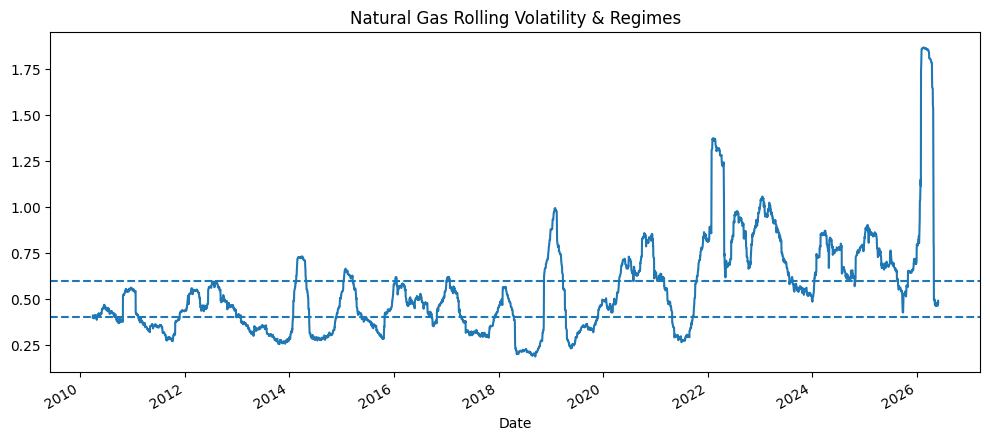

In [47]:
plt.figure(figsize=(12,5))
df_ng["NG_Volatility"].plot()
plt.axhline(low, linestyle="--")
plt.axhline(high, linestyle="--")
plt.title("Natural Gas Rolling Volatility & Regimes")
plt.show()